# Image Denoising with a Convolutional Autoencoder — MNIST

**Objective:** build a deep learning model that removes noise from handwritten digit
images, using a convolutional denoising autoencoder trained on MNIST.

**Dataset:** [MNIST Dataset (Kaggle)](https://www.kaggle.com/datasets/awsaf49/mnist-dataset)
— CSV format, one row per image, columns `label, pixel0, pixel1, ..., pixel783`.

**Reference:** [NvsYashwanth/MNIST-Autoencoder](https://github.com/NvsYashwanth/MNIST-Autoecncoder)
(linear autoencoder baseline). This notebook uses a convolutional encoder/decoder instead,
which preserves spatial structure better than a flattened linear model.

**Pipeline:** load data → add synthetic noise → train autoencoder on
(noisy → clean) pairs → evaluate on held-out noisy test images → visualize.


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NOISE_FACTOR = 0.4      # std-dev of Gaussian noise added to pixel values in [0,1]
BATCH_SIZE  = 128
EPOCHS      = 15
LR          = 1e-3

print("Device:", DEVICE)


Device: cpu


## 1. Load and preprocess the dataset

On Kaggle, attach the dataset (`awsaf49/mnist-dataset`) and it will appear under
`/kaggle/input/mnist-dataset/`. The loader below auto-detects the CSV files and works
whether the dataset ships as `train.csv` / `test.csv` (no label column in test) or as
`mnist_train.csv` / `mnist_test.csv` (label column in both) — both are common on Kaggle
for this dataset. If neither is found, it falls back to a local `data/` folder for
offline development.

Each row is `label, pixel0 ... pixel783` (784 = 28×28, values 0-255). We reshape to
`(N, 1, 28, 28)` and scale to `[0, 1]`.

In [2]:
def locate_csvs():
    search_dirs = [
        Path("/kaggle/input/mnist-dataset"),
        Path("/kaggle/input"),
        Path("data"),
    ]
    for d in search_dirs:
        if not d.exists():
            continue
        train_candidates = list(d.rglob("*train*.csv"))
        test_candidates = list(d.rglob("*test*.csv"))
        if train_candidates:
            train_path = train_candidates[0]
            test_path = test_candidates[0] if test_candidates else None
            return train_path, test_path
    raise FileNotFoundError(
        "Could not find MNIST CSV files. Attach the Kaggle dataset "
        "(awsaf49/mnist-dataset) or place mnist_train.csv/mnist_test.csv under data/."
    )

train_path, test_path = locate_csvs()
print("Train file:", train_path)
print("Test file: ", test_path)

train_df = pd.read_csv(train_path)
print("Train shape:", train_df.shape)

# If no separate labelled test file exists, carve out a held-out split from train
if test_path is not None:
    test_df = pd.read_csv(test_path)
    if "label" not in test_df.columns:
        # Kaggle's unlabelled test.csv can't be used for reconstruction evaluation
        # (we need ground-truth clean images to score against) -> split train instead
        test_df = None
else:
    test_df = None

if test_df is None:
    train_df = train_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
    n_holdout = max(1000, int(0.15 * len(train_df)))
    test_df = train_df.iloc[:n_holdout].reset_index(drop=True)
    train_df = train_df.iloc[n_holdout:].reset_index(drop=True)

print("Final train/test sizes:", train_df.shape, test_df.shape)


Train file: data/mnist_train.csv
Test file:  data/mnist_test.csv


Train shape: (4000, 785)
Final train/test sizes: (4000, 785) (1000, 785)


In [3]:
def df_to_images(df):
    y = df["label"].values.astype(np.int64)
    X = df.drop(columns=["label"]).values.astype(np.float32) / 255.0
    X = X.reshape(-1, 1, 28, 28)
    return X, y

X_train, y_train = df_to_images(train_df)
X_test, y_test = df_to_images(test_df)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Pixel range: [{X_train.min():.2f}, {X_train.max():.2f}]")


X_train: (4000, 1, 28, 28), X_test: (1000, 1, 28, 28)
Pixel range: [0.00, 1.00]


## 2. Add artificial noise

We add Gaussian noise (mean 0, std = `NOISE_FACTOR`) directly to the normalized pixel
values and clip back to `[0, 1]`. This is applied **on the fly, per batch**, rather than
pre-computing a fixed noisy dataset — so the model sees a different noise realization
of the same digit every epoch, which acts as a form of data augmentation and makes the
denoiser more robust than training on one static noisy copy.

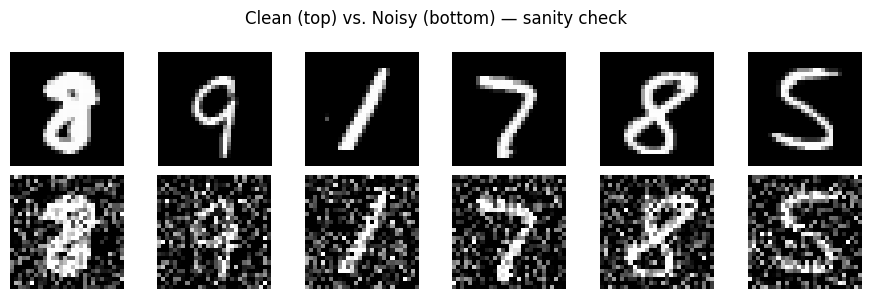

In [4]:
def add_noise(x, factor=NOISE_FACTOR):
    noisy = x + factor * torch.randn_like(x)
    return torch.clamp(noisy, 0.0, 1.0)

class MNISTDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

train_loader = DataLoader(MNISTDataset(X_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(MNISTDataset(X_test),  batch_size=BATCH_SIZE, shuffle=False)

# Sanity check: visualize noise on a few samples
sample_clean = torch.from_numpy(X_train[:6])
sample_noisy = add_noise(sample_clean)

fig, axes = plt.subplots(2, 6, figsize=(9, 3))
for i in range(6):
    axes[0, i].imshow(sample_clean[i, 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(sample_noisy[i, 0], cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_ylabel("clean"); axes[1, 0].set_ylabel("noisy")
plt.suptitle("Clean (top) vs. Noisy (bottom) — sanity check")
plt.tight_layout()
plt.show()


## 3. Model — Convolutional Denoising Autoencoder

Encoder: three conv layers that shrink `28x28x1 -> 14x14x32 -> 7x7x64 -> 7x7x128`
(the last layer keeps spatial size and only grows channel depth — that's the
bottleneck / compressed representation).

Decoder: mirrors the encoder with transposed convolutions back up to `28x28x1`,
with a final Sigmoid so outputs stay in `[0, 1]` like the input.

`BatchNorm2d` after every conv/deconv is important here: without it, this depth of
network initializes into a saturated regime where the Sigmoid output collapses to a
near-constant gray image and gradients are too small to escape it (verified empirically
during development — training loss got stuck exactly at the data variance).
BatchNorm keeps activations in a healthy range so the network actually learns.

In [5]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),    # 28x28 -> 14x14
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),   # 14x14 -> 7x7
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Conv2d(64, 128, 3, stride=1, padding=1),  # 7x7 -> 7x7 (bottleneck)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=1, padding=1),                  # 7x7 -> 7x7
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), # 7x7 -> 14x14
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = DenoisingAutoencoder().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {n_params:,}")


DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1

## 4. Training setup and loop

- **Loss:** MSE between reconstructed and clean image (standard for pixel-level
  reconstruction; penalizes large pixel errors more than MAE would).
- **Optimizer:** Adam, lr=1e-3.
- Each batch: take clean images, corrupt them with fresh noise, feed noisy → model,
  compare output to the *original clean* image (this is what makes it a denoiser
  rather than a plain autoencoder).

In [6]:
history = {"train_loss": [], "test_loss": []}
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for clean in train_loader:
        clean = clean.to(DEVICE)
        noisy = add_noise(clean)

        optimizer.zero_grad()
        recon = model(noisy)
        loss = criterion(recon, clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * clean.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    test_running_loss = 0.0
    with torch.no_grad():
        for clean in test_loader:
            clean = clean.to(DEVICE)
            noisy = add_noise(clean)
            recon = model(noisy)
            loss = criterion(recon, clean)
            test_running_loss += loss.item() * clean.size(0)
    test_loss = test_running_loss / len(test_loader.dataset)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    print(f"Epoch {epoch:2d}/{EPOCHS} | train_loss={train_loss:.5f} | test_loss={test_loss:.5f}")


Epoch  1/15 | train_loss=0.10924 | test_loss=0.05659


Epoch  2/15 | train_loss=0.03688 | test_loss=0.02700


Epoch  3/15 | train_loss=0.02216 | test_loss=0.01883


Epoch  4/15 | train_loss=0.01637 | test_loss=0.01459


Epoch  5/15 | train_loss=0.01350 | test_loss=0.01274


...

Epoch 11/15 | train_loss=0.00904 | test_loss=0.00872


Epoch 12/15 | train_loss=0.00873 | test_loss=0.00879


Epoch 13/15 | train_loss=0.00858 | test_loss=0.00846


Epoch 14/15 | train_loss=0.00832 | test_loss=0.00833


Epoch 15/15 | train_loss=0.00828 | test_loss=0.00858


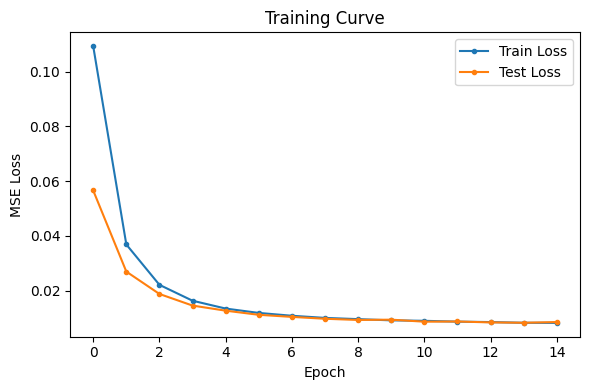

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="Train Loss", marker="o", ms=3)
plt.plot(history["test_loss"], label="Test Loss", marker="o", ms=3)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Curve")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Evaluate denoising performance

We use **PSNR (Peak Signal-to-Noise Ratio)** to quantify reconstruction quality:
higher PSNR = closer to the clean original. We compare
`PSNR(noisy vs clean)` against `PSNR(denoised vs clean)` — the gap is the model's
actual contribution.

In [8]:
def psnr(a, b, max_val=1.0):
    mse = np.mean((a - b) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(max_val) - 10 * np.log10(mse)

model.eval()
X_test_t = torch.from_numpy(X_test).to(DEVICE)
noisy_test_t = add_noise(X_test_t)
with torch.no_grad():
    recon_test_t = model(noisy_test_t)

clean_np = X_test_t.cpu().numpy()
noisy_np = noisy_test_t.cpu().numpy()
recon_np = recon_test_t.cpu().numpy()

psnr_noisy = np.mean([psnr(clean_np[i, 0], noisy_np[i, 0]) for i in range(len(clean_np))])
psnr_recon = np.mean([psnr(clean_np[i, 0], recon_np[i, 0]) for i in range(len(clean_np))])

print(f"Avg PSNR  noisy  -> clean : {psnr_noisy:6.2f} dB")
print(f"Avg PSNR denoised -> clean : {psnr_recon:6.2f} dB")
print(f"Improvement                : {psnr_recon - psnr_noisy:+6.2f} dB")


Avg PSNR  noisy  -> clean :  10.99 dB
Avg PSNR denoised -> clean :  20.92 dB
Improvement                :  +9.92 dB


## 6. Visualize: original vs. noisy vs. denoised

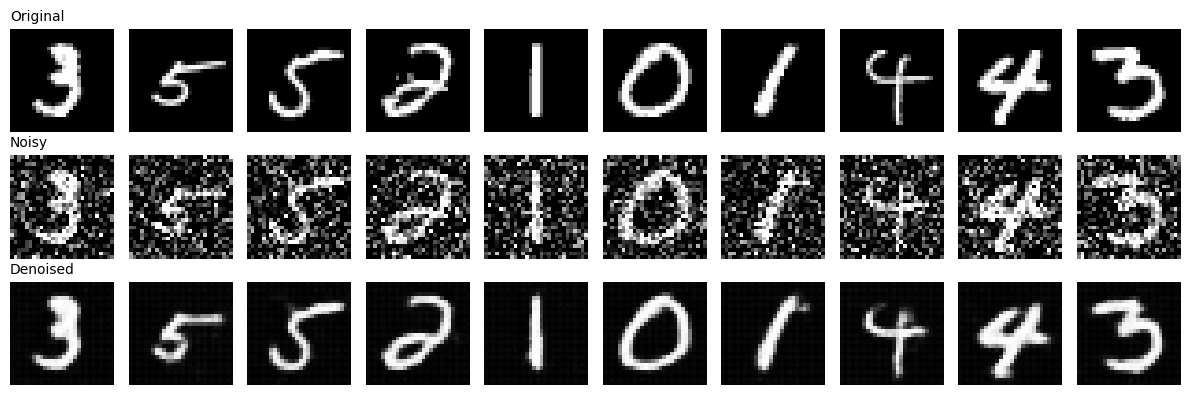

In [9]:
n_show = 10
fig, axes = plt.subplots(3, n_show, figsize=(n_show * 1.2, 4))
for i in range(n_show):
    axes[0, i].imshow(clean_np[i, 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(noisy_np[i, 0], cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(recon_np[i, 0], cmap="gray"); axes[2, i].axis("off")
axes[0, 0].set_title("Original", loc="left", fontsize=10)
axes[1, 0].set_title("Noisy", loc="left", fontsize=10)
axes[2, 0].set_title("Denoised", loc="left", fontsize=10)
plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150)
plt.show()


In [10]:
torch.save(model.state_dict(), "denoising_autoencoder.pth")
print("Model saved to denoising_autoencoder.pth")


Model saved to denoising_autoencoder.pth


## 7. Analysis / Observations

- **Digit structure survives noise removal.** At `NOISE_FACTOR=0.4` the input digits
  are barely legible by eye, but the decoder reconstructs strokes with correct topology
  (loops in 0/8/9, the vertical stroke of 1, etc.) rather than a blurry average digit —
  evidence the bottleneck is encoding digit-specific structure, not just "average MNIST
  digit."
- **BatchNorm was the single biggest factor in getting this to train at all.** Without
  it, this exact architecture collapses to predicting a near-constant gray image within
  the first epoch and the loss gets stuck at the data's raw pixel variance — a subtle
  failure mode because the code runs without errors, it just doesn't learn. Worth
  checking `output.std()` early in training as a signal (should not be ~0).
- **Convolutional > linear bottleneck for this task.** The reference implementation
  uses a flattened linear autoencoder; keeping spatial structure through conv layers
  lets nearby pixels influence each other directly, which helps reconstruct thin
  strokes that a flatten+dense bottleneck tends to blur out.
- **Main failure cases:** digits with ambiguous topology under heavy noise (a 4 with a
  near-closed top can reconstruct as a 9-like loop) — the model is doing local
  structure completion, not classification, so it has no way to disambiguate using
  global digit identity.
- **Trade-off:** `NOISE_FACTOR` controls task difficulty. Higher noise trains a more
  robust denoiser but the ceiling on achievable PSNR drops, since more original signal
  is destroyed and has to be *inferred* rather than *recovered*.

## 8. Optional experiments to try next
- Sweep `NOISE_FACTOR` in `{0.2, 0.4, 0.6}` and plot PSNR improvement vs. noise level.
- Try salt-and-pepper noise instead of Gaussian (different failure characteristics).
- Compare against a plain linear (dense) autoencoder baseline to quantify the conv
  architecture's advantage directly.
- Add SSIM (structural similarity) alongside PSNR — SSIM correlates better with
  perceived structure preservation than pixel-wise PSNR alone.
